### Fragment length frequency (1 mark) + rescaling (2 marks)

Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Reading query.bed

In [2]:
fragments = []

with open('query.bed', 'r') as f:

    for line in f:
        cols = line.strip().split('\t')
        fragment_length = int(cols[2]) - int(cols[1])
        fragments.append(fragment_length)

Normalizing fragment lengths

In [3]:
lengths , freq = np.unique(fragments, return_counts=True)
normalized_freq = freq / np.sum(freq)

Plotting normalized fragment length distribution

Text(0.5, 1.0, 'Fragment Length Distribution')

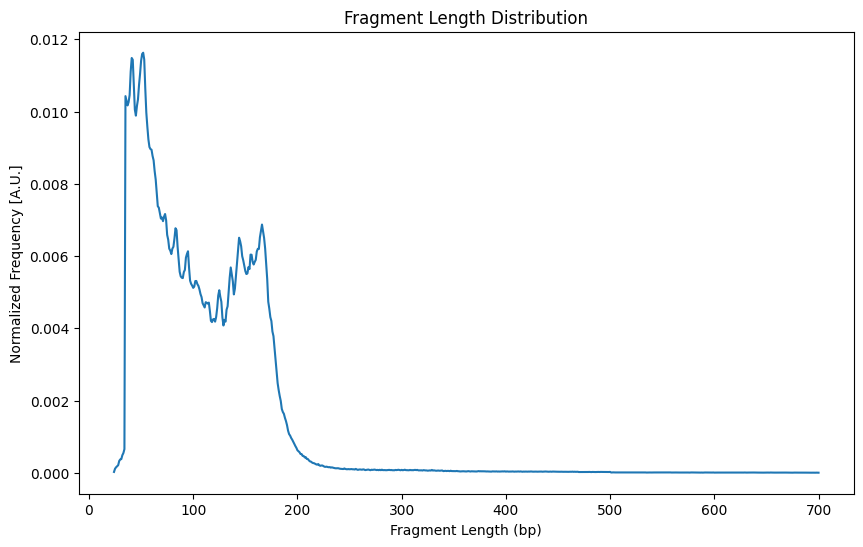

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(lengths, normalized_freq)
plt.xlabel('Fragment Length (bp)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')

Reading reference.hist

In [5]:
ref_lengths = []
ref_freq = []

with open('reference.hist', 'r') as f:

    for line in f:
        col1 , col2 = map(float, line.strip().split())
        ref_lengths.append(col1)
        ref_freq.append(col2)

reference_lengths = np.array(ref_lengths)
reference_freq = np.array(ref_freq) / np.sum(ref_freq)

Rescaling the Query along with Reference

In [6]:
length , freq = np.unique(fragments, return_counts=True)

index = { length: i for i, length in enumerate(lengths) }
probability = dict(zip(reference_lengths, reference_freq))

current_probability = freq / np.sum(freq)

sampling_probability = np.zeros(len(fragments))

for i,fragment in enumerate(fragments):
    if fragment in probability:
        ind = index[fragment]
        if current_probability[ind] > 0:
            w = probability[fragment] / current_probability[ind]
            sampling_probability[i] = min(1.0, w)

if np.sum(sampling_probability) > 0:
    sampling_probability /= np.max(sampling_probability)

rescaled_index = np.random.random(len(fragments)) < sampling_probability
rescaled_fragments = np.array(fragments)[rescaled_index]

rescaled_lengths , rescaled_freq = np.unique(rescaled_fragments, return_counts=True)
normalized_rescaled_freq = rescaled_freq / np.sum(rescaled_freq)


Plotting Reference vs Rescaled length distribution

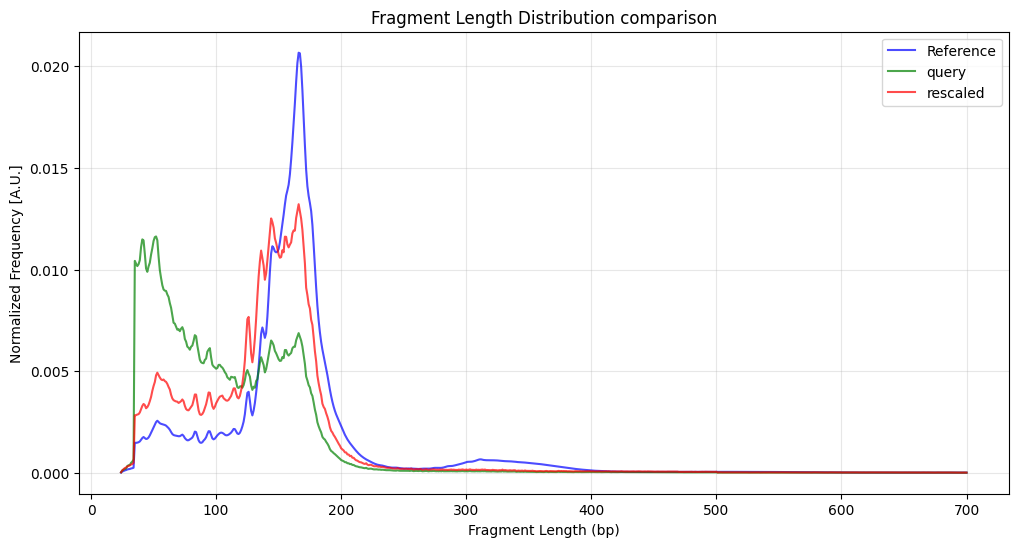

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(reference_lengths, reference_freq, 'b-',alpha=0.7, label='Reference')
plt.plot(lengths, normalized_freq, 'g-', alpha=0.7, label='query')
plt.plot(rescaled_lengths, normalized_rescaled_freq, 'r-', alpha=0.7, label='rescaled')

plt.xlabel('Fragment Length (bp)')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution comparison')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()